# 1. Import Libraries

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.6 MB/s eta 0:00:00


In [2]:
# Standard libraries
import os
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP NLTK
import nltk
nltk.download('punkt', quiet = True)
nltk.download('punkt_tab', quiet = True)
nltk.download('stopwords', quiet = True)
nltk.download('wordnet', quiet = True)
nltk.download('omw-1.4', quiet = True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import joblib

# Word2Vec
from gensim.models import Word2Vec


# 2. Load & Inspect Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [4]:
# Load the raw CSV
df_raw = pd.read_csv('spam.csv', encoding = 'latin-1')

print('Shape:', df_raw.shape)
print('\nColumn names:', df_raw.columns.tolist())
print('\nFirst 5 rows:')
df_raw.head()

Shape: (5572, 5)

Column names: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# 3. Data Cleaning

In [5]:
# Keep only the two relevant columns and rename them
df = df_raw[['v1', 'v2']].copy()
df.columns = ['label', 'text']

In [6]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
label    0
text     0
dtype: int64


In [7]:
# Check for duplicates
print('Number of duplicate rows:')
print(df.duplicated().sum())

df[df.duplicated()]

Number of duplicate rows:
403


,label,text
102,ham,As per your request 'Melle Melle (Oru Minnamin...
153,ham,As per your request 'Melle Melle (Oru Minnamin...
206,ham,"As I entered my cabin my PA said, '' Happy B'd..."
222,ham,"Sorry, I'll call later"
325,ham,No calls..messages..missed calls
...,...,...
5524,spam,You are awarded a SiPix Digital Camera! call 0...
5535,ham,"I know you are thinkin malaria. But relax, chi..."
5539,ham,Just sleeping..and surfing
5553,ham,Hahaha..use your brain dear


In [8]:
# Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace = True)
after = len(df)
print(f'Duplicate rows removed: {before - after}')
print(f'Dataset size after cleaning: {after} rows')

Duplicate rows removed: 403
Dataset size after cleaning: 5169 rows


In [9]:
# Reset index
df.reset_index(drop=True, inplace=True)

print('\nSample rows after cleaning:')
df.head(10)


Sample rows after cleaning:


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [10]:
# Encode labels: ham = 0, spam = 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print('Label encoding:')
print(df[['label', 'label_num']].drop_duplicates())
print('\nFinal dataset shape:', df.shape)

Label encoding:
  label  label_num
0   ham          0
2  spam          1

Final dataset shape: (5169, 3)


# 4. Exploratory Data Analysis (EDA)

In [11]:
# Class distribution
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

print('Class Distribution:')
print('-' * 30)
for label in class_counts.index:
  print(f' {label:>4} -> {class_counts[label]:>5} samples ({class_pct[label]:.1f}%)')
print('-' * 30)
print(f' Total -> {len(df):>5} samples')

Class Distribution:
------------------------------
  ham ->  4516 samples (87.4%)
 spam ->   653 samples (12.6%)
------------------------------
 Total ->  5169 samples


In [12]:
# Text length statistics
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['char_count'] = df['text'].apply(len)

print('Text length statistics: (word count) by class:')
print(df.groupby('label')['word_count'].describe().round(2))

Text length statistics: (word count) by class:
        count   mean    std  min   25%   50%   75%    max
label                                                    
ham    4516.0  14.13  11.12  1.0   7.0  11.0  18.0  171.0
spam    653.0  23.68   5.97  2.0  22.0  25.0  28.0   35.0


In [13]:
# Sample messages per class
print('Sample HAM messages:')
print('-' * 60)
for msg in df[df['label'] == 'ham']['text'].head(3).values:
  print(f' • {msg}')

print('\nSample SPAM messages:')
print('-' * 60)
for msg in df[df['label'] == 'spam']['text'].head(3).values:
  print(f' • {msg}')

Sample HAM messages:
------------------------------------------------------------
 • Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
 • Ok lar... Joking wif u oni...
 • U dun say so early hor... U c already then say...

Sample SPAM messages:
------------------------------------------------------------
 • Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
 • FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
 • WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.


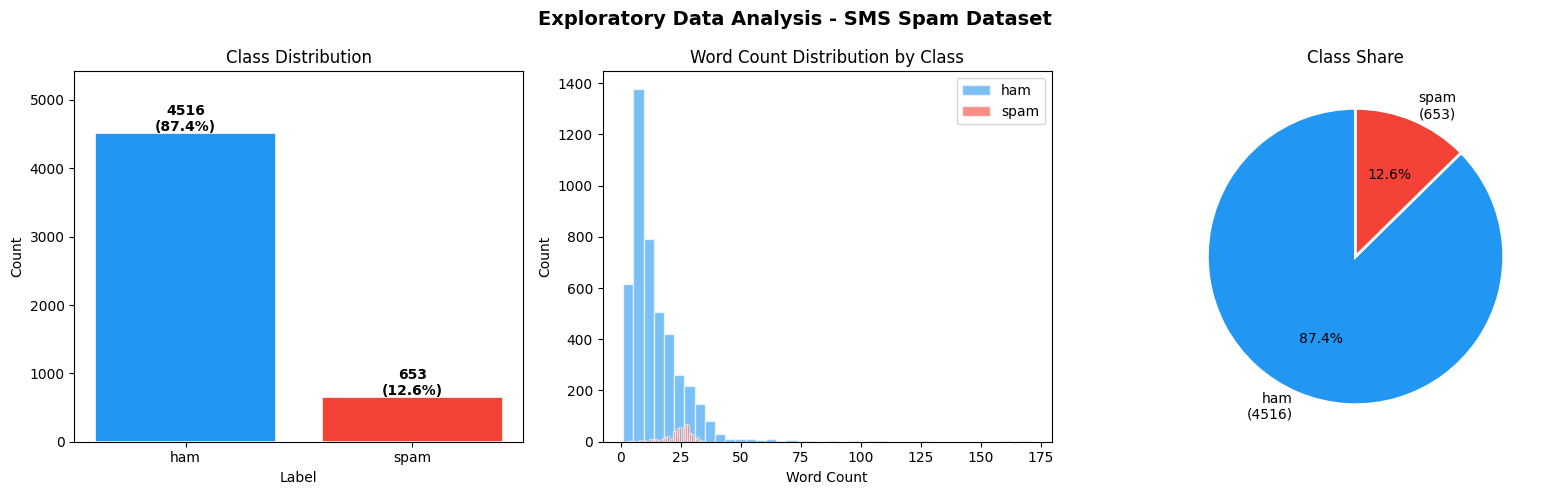

EDA hart saved as eda_overview.png


In [14]:
# Visualizations
fig, axes = plt.subplots(1, 3, figsize= (16,5))
fig.suptitle('Exploratory Data Analysis - SMS Spam Dataset', fontsize=14, fontweight='bold')

# Plot 1: Class distribution bar chart
colors = ['#2196F3', '#F44336']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
for i, (label, count) in enumerate(class_counts.items()):
  axes[0].text(i, count + 30, f'{count}\n({class_pct[label]:.1f}%)',
               ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(class_counts.values) * 1.2)

# Plot 2: Word count distribution by class
for label, color in zip(['ham', 'spam'], colors):
  axes[1].hist(df[df['label'] == label]['word_count'],
               bins=40, alpha=0.6, label=label, color=color, edgecolor='white')
axes[1].set_title('Word Count Distribution by Class')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Count')
axes[1].legend()

# Plot 3: Pie Chart
axes[2].pie(class_counts.values,
            labels=[f'{l}\n({v})' for l, v in zip(class_counts.index, class_counts.values)],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth':2})
axes[2].set_title('Class Share')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA hart saved as eda_overview.png')

# 5. Text Preprocessing Pipeline

Clean and normalise a raw SMS message.

Steps:


1.   Lowercase
2.   Remove URLs, mentions, special characters, and numbers
3.   Tokenize
4.   Remove stopwords
5.   Lemmatize

Args:


*   text (str): Raw input message

Returns:



*   str: Fully cleaned and
normalised text










In [15]:
# Define the preprocessing function
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

def preprocess(text: str) -> str:
  # Step 1: Lowercase
  text = text.lower()

  # Step 2: Noise removal
  text = re.sub(r'http\S+|www\S+',  ' ', text) # remove URLs
  text = re.sub(r'@\w+',            ' ', text) # remove @mentions
  text = re.sub(r'#\w+',            ' ', text) # remove hashtags
  text = re.sub(r'<.*?>',           ' ', text) # remove HTML tags
  text = re.sub(r'\d+',             ' ', text) # remove numbers
  text = re.sub(r'[^\w\s]',         ' ', text) # remove punctuation
  text = re.sub(r'[^a-z\s]',        ' ', text) # remove anything not a letter
  text = re.sub(r'\s+',             ' ', text).strip() # collapse extra spaces

  # Step 3: Tokenize
  tokens = word_tokenize(text)

  # Step 4: Remove stopwords
  tokens = [t for t in tokens if t not in STOP_WORDS]

  # Step 5: Lemmatize
  tokens = [lemmatizer.lemmatize(t) for t in tokens]

  return ' '.join(tokens)

print('preprocess() function defined.')

preprocess() function defined.


In [16]:
# Before and After Example
example_spam = "WINNER!!! As a valued network customer you have been selected to receive RM1000 prize reward! Call 09061701461 to claim. Valid 12 hours only."
example_ham = "Hey, are you coming to the meeting tomorrow at 10am? Let me know!"

print(f'--- Before and After Example ---')
print(f'SPAM raw: {example_spam}')
print(f'SPAM clean: {preprocess(example_spam)}')
print(f'\nHAM raw: {example_ham}')
print(f'HAM clean: {preprocess(example_ham)}')

--- Before and After Example ---
SPAM raw: WINNER!!! As a valued network customer you have been selected to receive RM1000 prize reward! Call 09061701461 to claim. Valid 12 hours only.
SPAM clean: winner valued network customer selected receive rm prize reward call claim valid hour

HAM raw: Hey, are you coming to the meeting tomorrow at 10am? Let me know!
HAM clean: hey coming meeting tomorrow let know


In [17]:
# Apply preprocessing to the full dataset
print('Applying preprocessing pipeline to the full dataset')
df['text_clean'] = df['text'].apply(preprocess)

print(f'Done. {len(df)} messages processed.')
print('\nSample output:')
df[['label', 'text', 'text_clean']].head(6)

Applying preprocessing pipeline to the full dataset
Done. 5169 messages processed.

Sample output:


,label,text,text_clean
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back like fun st...


In [18]:
# Save the cleaned dataset
df[['label', 'label_num', 'text', 'text_clean']].to_csv('cleaned_data.csv', index = False)
print('Cleaned dataset saved as "cleaned_data.csv"')
print('Columns saved:', ['label', 'label_num', 'text', 'text_clean'])

Cleaned dataset saved as "cleaned_data.csv"
Columns saved: ['label', 'label_num', 'text', 'text_clean']


In [19]:
# Save preprocess() as a reusable module
%%writefile utils.py

import re
import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

def preprocess(text: str) -> str:
    """
    Clean and normalise a raw SMS message.
    Used by both the training notebook (Member 2) and the Streamlit app (Member 3).
    DO NOT modify this function — any change will break model predictions.
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+',           ' ', text)
    text = re.sub(r'#\w+',           ' ', text)
    text = re.sub(r'<.*?>',          ' ', text)
    text = re.sub(r'\d+',            ' ', text)
    text = re.sub(r'[^\w\s]',        ' ', text)
    text = re.sub(r'[^a-z\s]',       ' ', text)
    text = re.sub(r'\s+',            ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

Writing utils.py


# 6. Feature Extraction -- Method 1: TF-IDF

In [20]:
# Train / Test split
X = df['text_clean']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print('Train/Test split (80/20, stratified):')
print(f' Training set: {len(X_train)} samples')
print(f' Test set: {len(X_test)} samples')
print(f'\nClass ratio in training set:')
print(y_train.value_counts(normalize=True).round(3))

Train/Test split (80/20, stratified):
 Training set: 4135 samples
 Test set: 1034 samples

Class ratio in training set:
label_num
0    0.874
1    0.126
Name: proportion, dtype: float64


In [21]:
# Fit TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    ngram_range = (1,2),    # unigrams and bigrams
    max_features = 10000,   # cap vocabulary at 10,000 most important terms
    sublinear_tf = True     # apply log normalisation to term frequency
)

# Fit on training set only
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF vectorizer fitted.')
print(f' Vocabulary size: {len(tfidf.vocabulary_):,} terms')
print(f' Training matrix: {X_train_tfidf.shape}')
print(f' Test matrix: {X_test_tfidf.shape}')

TF-IDF vectorizer fitted.
 Vocabulary size: 10,000 terms
 Training matrix: (4135, 10000)
 Test matrix: (1034, 10000)


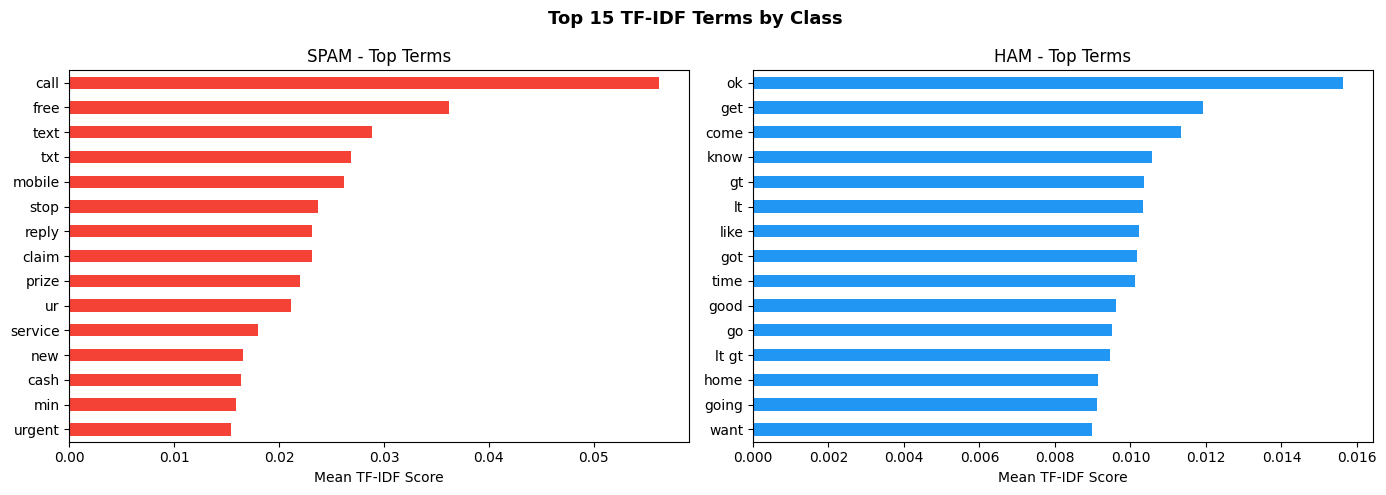

Chart saved as tfidf_top_terms.png


In [22]:
# Top TF-IDF terms by class
feature_names = tfidf.get_feature_names_out()

# Get mean TF-IDF score per class
spam_idx = y_train[y_train == 1].index
ham_idx = y_train[y_train == 0].index

# Map to positional indices within X_train
X_train_reset = X_train.reset_index(drop=True)
spam_pos = [i for i, idx in enumerate(X_train.index) if idx in spam_idx]
ham_pos = [i for i, idx in enumerate(X_train.index) if idx in ham_idx]

spam_scores = X_train_tfidf[spam_pos].mean(axis=0).A1
ham_scores = X_train_tfidf[ham_pos].mean(axis=0).A1

top_spam = pd.Series(spam_scores, index=feature_names).nlargest(15)
top_ham = pd.Series(ham_scores, index=feature_names).nlargest(15)

fig, axes = plt.subplots(1,2, figsize=(14,5))
fig.suptitle('Top 15 TF-IDF Terms by Class', fontsize=13, fontweight='bold')

top_spam.sort_values().plot(kind='barh', ax=axes[0], color='#F44336')
axes[0].set_title('SPAM - Top Terms')
axes[0].set_xlabel('Mean TF-IDF Score')

top_ham.sort_values().plot(kind='barh', ax=axes[1], color='#2196F3')
axes[1].set_title('HAM - Top Terms')
axes[1].set_xlabel('Mean TF-IDF Score')

plt.tight_layout()
plt.savefig('tfidf_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as tfidf_top_terms.png')

In [23]:
# Save the fitted TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print('TF-IDF vectorizer saved as tfidf_vectorizer.pkl')

TF-IDF vectorizer saved as tfidf_vectorizer.pkl


# 7. Feature Extraction -- Method 2: Word2Vec

In [24]:
# Prepare tokenised corpus for Word2Vec
# Word2Vec requires a list of token lists

train_tokens = [text.split() for text in X_train]
test_tokens = [text.split() for text in X_test]

print(f'Training corpus: {len(train_tokens)} messages')
print(f'Example tokens: {train_tokens[0]}')

Training corpus: 4135 messages
Example tokens: ['cool', 'come', 'havent', 'wined', 'dined']


In [25]:
# Train Word2Vec model
w2v_model = Word2Vec(
    sentences = train_tokens,
    vector_size = 100,
    window = 5,
    min_count = 2,
    workers = 4,
    epochs = 10,
    seed = 42
)

print('Word2Vec model trained.')
print(f'Vocabulary size: {len(w2v_model.wv):,} words')

# Show most similar words to 'free'
if 'free' in w2v_model.wv:
  print("\nTop5 words most similar to 'free' in this corpus:")
  for word, score in w2v_model.wv.most_similar('free', topn=5):
    print(f' {word:<15} similarity: {score:.3f}')

Word2Vec model trained.
Vocabulary size: 2,831 words

Top5 words most similar to 'free' in this corpus:
 mobile          similarity: 0.998
 reply           similarity: 0.997
 txt             similarity: 0.997
 tone            similarity: 0.997
 nokia           similarity: 0.997


In [26]:
# Convert messages to averaged Word2Vec vectors
def message_to_vector(tokens, model, vector_size=100):
  known = [model.wv[t] for t in tokens if t in model.wv]
  if not known:
    return np.zeros(vector_size)
  return np.mean(known, axis=0)

X_train_w2v = np.array([message_to_vector(t, w2v_model) for t in train_tokens])
X_test_w2v = np.array([message_to_vector(t, w2v_model) for t in test_tokens])

print('Word2Vec message vectors created.')
print(f' Training matrix shape: {X_train_w2v.shape}')
print(f' Test matrix shape: {X_test_w2v.shape}')

Word2Vec message vectors created.
 Training matrix shape: (4135, 100)
 Test matrix shape: (1034, 100)


In [27]:
# Save Word2Vec model as a single file
w2v_model.wv.save_word2vec_format('word2vec_vectors.bin', binary=True)
print('Word2Vec vectors saved as word2vec_vectors.bin')

Word2Vec vectors saved as word2vec_vectors.bin


# 8. Summary of NLP Pipeline

In [28]:
# Output Summary
print('=' * 55)
print('  NLP Pipeline — OUTPUT SUMMARY')
print('=' * 55)

outputs = {
    'cleaned_data.csv'      : 'Cleaned and preprocessed dataset',
    'utils.py'              : 'Text preprocessing module',
    'tfidf_vectorizer.pkl'  : 'Fitted TF-IDF vectorizer',
    'word2vec_vectors.bin'  : 'Trained Word2Vec vectors',
    'tfidf_top_terms.png'   : 'Top TF-IDF terms visualisation',
    'eda_overview.png'      : 'Exploratory data analysis charts',
}

for filename, description in outputs.items():
    exists = '✓' if os.path.exists(filename) else '✗ MISSING'
    print(f'  [{exists}]  {filename}')
    print(f'          {description}')

print('=' * 55)

  NLP Pipeline — OUTPUT SUMMARY
  [✓]  cleaned_data.csv
          Cleaned and preprocessed dataset
  [✓]  utils.py
          Text preprocessing module
  [✓]  tfidf_vectorizer.pkl
          Fitted TF-IDF vectorizer
  [✓]  word2vec_vectors.bin
          Trained Word2Vec vectors
  [✓]  tfidf_top_terms.png
          Top TF-IDF terms visualisation
  [✓]  eda_overview.png
          Exploratory data analysis charts


## **2.3 Model Training**

### **2.3.1 Baseline Naive Bayes Model**

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

print("Training Baseline Model: Multinomial Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluation
acc_nb = accuracy_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {acc_nb:.4f}")
print("\nClassification Report (Naive Bayes):\n")
print(classification_report(y_test, y_pred_nb, target_names=['Ham (0)', 'Spam (1)']))
print("Confusion Matrix (Naive Bayes) [[TN, FP], [FN, TP]]:\n", cm_nb)

Training Baseline Model: Multinomial Naive Bayes...
Naive Bayes Accuracy: 0.9613

Classification Report (Naive Bayes):

              precision    recall  f1-score   support

     Ham (0)       0.96      1.00      0.98       903
    Spam (1)       1.00      0.69      0.82       131

    accuracy                           0.96      1034
   macro avg       0.98      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034

Confusion Matrix (Naive Bayes) [[TN, FP], [FN, TP]]:
 [[903   0]
 [ 40  91]]


### **2.3.2 Logistic Regression with GridSearchCV**

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

print("Training Logistic Regression with GridSearchCV...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)

param_grid = {'C': [0.1, 1.0, 10.0]}

# We select on F1, not raw accuracy, because the dataset is imbalanced
# (87.4% ham / 12.6% spam) — a model that just predicts "ham" every time
# would score ~87% accuracy while being useless. We still record CV accuracy
# below for the report, alongside the metric we actually optimise for.
grid_search = GridSearchCV(
    log_reg, param_grid, cv=5,
    scoring=['accuracy', 'f1'], refit='f1'
)
grid_search.fit(X_train_tfidf, y_train)

best_lr = grid_search.best_estimator_
i = grid_search.best_index_

cv_acc_mean = grid_search.cv_results_['mean_test_accuracy'][i]
cv_acc_std  = grid_search.cv_results_['std_test_accuracy'][i]
cv_f1_mean  = grid_search.cv_results_['mean_test_f1'][i]
cv_f1_std   = grid_search.cv_results_['std_test_f1'][i]

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"CV Accuracy: {cv_acc_mean:.4f} ± {cv_acc_std:.4f}")
print(f"CV F1-Score: {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")

# Evaluate best model on test set (GridSearchCV already refit on full train set)
y_pred_lr = best_lr.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f"\nLogistic Regression (Tuned) Accuracy: {acc_lr:.4f}")
print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_lr, target_names=['Ham (0)', 'Spam (1)']))
print("Confusion Matrix (Logistic Regression) [[TN, FP], [FN, TP]]:\n", cm_lr)

Training Logistic Regression with GridSearchCV...
Best Hyperparameters: {'C': 10.0}
CV Accuracy: 0.9727 ± 0.0047
CV F1-Score: 0.8798 ± 0.0235

Logistic Regression (Tuned) Accuracy: 0.9816

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       903
    Spam (1)       0.97      0.89      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034

Confusion Matrix (Logistic Regression) [[TN, FP], [FN, TP]]:
 [[899   4]
 [ 15 116]]


In [31]:
# 11. Which class is hardest to classify?
class_names = {0: 'Ham', 1: 'Spam'}

print("="*55)
print(" Per-Class Difficulty Analysis")
print("="*55)

for name, y_pred in [('Naive Bayes', y_pred_nb), ('Logistic Regression', y_pred_lr)]:
    p, r, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[0, 1])
    print(f"\n{name}:")
    for c in [0, 1]:
        print(f"  {class_names[c]:<5} -> Precision: {p[c]:.3f} | Recall: {r[c]:.3f} | "
              f"F1: {f1[c]:.3f} | Support: {support[c]}")
    hardest = 0 if f1[0] < f1[1] else 1
    print(f"  -> Harder class for {name}: {class_names[hardest]} (lower F1 = {f1[hardest]:.3f})")

 Per-Class Difficulty Analysis

Naive Bayes:
  Ham   -> Precision: 0.958 | Recall: 1.000 | F1: 0.978 | Support: 903
  Spam  -> Precision: 1.000 | Recall: 0.695 | F1: 0.820 | Support: 131
  -> Harder class for Naive Bayes: Spam (lower F1 = 0.820)

Logistic Regression:
  Ham   -> Precision: 0.984 | Recall: 0.996 | F1: 0.990 | Support: 903
  Spam  -> Precision: 0.967 | Recall: 0.885 | F1: 0.924 | Support: 131
  -> Harder class for Logistic Regression: Spam (lower F1 = 0.924)


In [33]:
# 12. Feature-method comparison: Logistic Regression on Word2Vec vectors
print("Training Logistic Regression on Word2Vec features (feature-method comparison)...")
lr_w2v = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_w2v.fit(X_train_w2v, y_train)

y_pred_w2v = lr_w2v.predict(X_test_w2v)
acc_w2v = accuracy_score(y_test, y_pred_w2v)
cm_w2v = confusion_matrix(y_test, y_pred_w2v)
metrics_w2v = precision_recall_fscore_support(y_test, y_pred_w2v, average='weighted')

print(f"Logistic Regression (Word2Vec) Accuracy: {acc_w2v:.4f}")
print(classification_report(y_test, y_pred_w2v, target_names=['Ham (0)', 'Spam (1)']))
print("Confusion Matrix (LR + Word2Vec):\n", cm_w2v)

Training Logistic Regression on Word2Vec features (feature-method comparison)...
Logistic Regression (Word2Vec) Accuracy: 0.9217
              precision    recall  f1-score   support

     Ham (0)       0.93      0.98      0.96       903
    Spam (1)       0.80      0.51      0.62       131

    accuracy                           0.92      1034
   macro avg       0.87      0.75      0.79      1034
weighted avg       0.92      0.92      0.91      1034

Confusion Matrix (LR + Word2Vec):
 [[886  17]
 [ 64  67]]


## **2.4 Model Evaluation**

In [35]:
# 13. Final Model Comparison & File Exports
import pandas as pd
import numpy as np
import joblib
import os
import shutil

print("Extracting metrics for all models...")
metrics_nb  = precision_recall_fscore_support(y_test, y_pred_nb,  average='weighted')
metrics_lr  = precision_recall_fscore_support(y_test, y_pred_lr,  average='weighted')
metrics_w2v = precision_recall_fscore_support(y_test, y_pred_w2v, average='weighted')

comparison_df = pd.DataFrame({
    'Model':     ['Naive Bayes (TF-IDF)', 'Logistic Regression (TF-IDF)', 'Logistic Regression (Word2Vec)'],
    'Accuracy':  [acc_nb, acc_lr, acc_w2v],
    'Precision': [metrics_nb[0], metrics_lr[0], metrics_w2v[0]],
    'Recall':    [metrics_nb[1], metrics_lr[1], metrics_w2v[1]],
    'F1-Score':  [metrics_nb[2], metrics_lr[2], metrics_w2v[2]]
}).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\nFinal Model Comparison:")
display(comparison_df)

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest model by F1-Score: {best_model_name}")

os.makedirs('models', exist_ok=True)

# Export 1: metrics table for Member 4
comparison_df.to_csv('models/model_comparison_metrics.csv', index=False)
print("[✔] Saved comparison metrics to 'models/model_comparison_metrics.csv'")

# Export 2: confusion matrices — now all three
np.savez('models/confusion_matrices.npz', nb=cm_nb, lr=cm_lr, lr_w2v=cm_w2v,
         class_names=np.array(['Ham', 'Spam']))
print("[✔] Saved confusion matrices to 'models/confusion_matrices.npz'")

# Export 3: best DEPLOYABLE model — restricted to the two TF-IDF models.
# lr_w2v's coefficients live in embedding space, not vocabulary space, so they
# can't drive the app's word-importance feature the way the other two can.
best_traditional_name = 'Naive Bayes (TF-IDF)' if metrics_nb[2] > metrics_lr[2] else 'Logistic Regression (TF-IDF)'
best_model_obj = nb_model if best_traditional_name == 'Naive Bayes (TF-IDF)' else best_lr
joblib.dump(best_model_obj, 'models/best_model.pkl')
print(f"[✔] Best deployable model ({best_traditional_name}) saved to 'models/best_model.pkl'")

if best_model_name != best_traditional_name:
    print(f"[i] Note: '{best_model_name}' scored highest overall but isn't deployed — "
          f"see report Section 3.2 for the interpretability rationale.")

# Export 4: feature importance for Member 3's "top words" UI
feature_names = tfidf.get_feature_names_out()
if hasattr(best_model_obj, 'coef_'):
    weights = best_model_obj.coef_[0]
else:
    weights = best_model_obj.feature_log_prob_[1] - best_model_obj.feature_log_prob_[0]

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Weight': weights}) \
    .sort_values(by='Weight', ascending=False)
feature_importance_df.to_csv('models/feature_weights.csv', index=False)
print("[✔] Feature weights saved to 'models/feature_weights.csv'")

# Export 5: consolidate vectorizers into models/
for fname in ['tfidf_vectorizer.pkl', 'word2vec_vectors.bin']:
    if os.path.exists(fname):
        shutil.copy(fname, f'models/{fname}')
        print(f"[✔] Copied {fname} into models/")
    else:
        print(f"[!] {fname} not found in this session — re-run Member 1's cells first")

Extracting metrics for all models...

Final Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (TF-IDF),0.981625,0.981445,0.981625,0.981278
1,Naive Bayes (TF-IDF),0.961315,0.962956,0.961315,0.958249
2,Logistic Regression (Word2Vec),0.921663,0.915527,0.921663,0.914095



Best model by F1-Score: Logistic Regression (TF-IDF)
[✔] Saved comparison metrics to 'models/model_comparison_metrics.csv'
[✔] Saved confusion matrices to 'models/confusion_matrices.npz'
[✔] Best deployable model (Logistic Regression (TF-IDF)) saved to 'models/best_model.pkl'
[✔] Feature weights saved to 'models/feature_weights.csv'
[✔] Copied tfidf_vectorizer.pkl into models/
[✔] Copied word2vec_vectors.bin into models/
